In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [6]:
try:
    housing_df = pd.read_csv('housing_price_dataset.csv')
    print("File 'housing_price_dataset.csv' loaded successfully.")

    target_column = 'Price'

    numeric_features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
    categorical_features = []

    X = housing_df[numeric_features + categorical_features]
    y = housing_df[target_column]

    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')

    transformers_list = [
        ('num', numeric_transformer, numeric_features)
    ]

    if categorical_features:
        transformers_list.append(('cat', categorical_transformer, categorical_features))

    preprocessor = ColumnTransformer(
        transformers=transformers_list)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Data processing and splitting complete.")

except FileNotFoundError:
    print("Error: 'housing_price_dataset.csv' not found.")
    print("Please upload the file to your Colab session.")
except KeyError as e:
    print(f"KeyError: {e}. Please check and correct the column names in Cell 2.")
except Exception as e:
    print(f"An error occurred: {e}")

File 'housing_price_dataset.csv' loaded successfully.
Data processing and splitting complete.



--- Training L1 (Lasso) Model ---
Best Lasso Alpha: 0.1
Lasso Model R-squared (R²): 0.9180


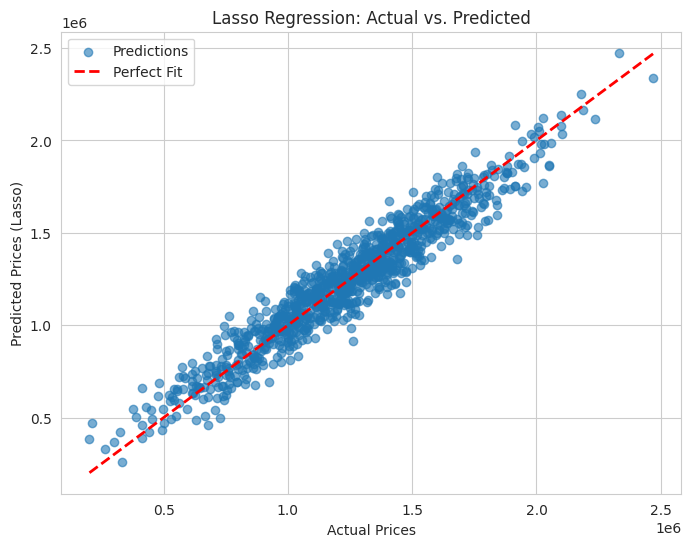


--- Training L2 (Ridge) Model ---
Best Ridge Alpha: 0.1
Ridge Model R-squared (R²): 0.9180


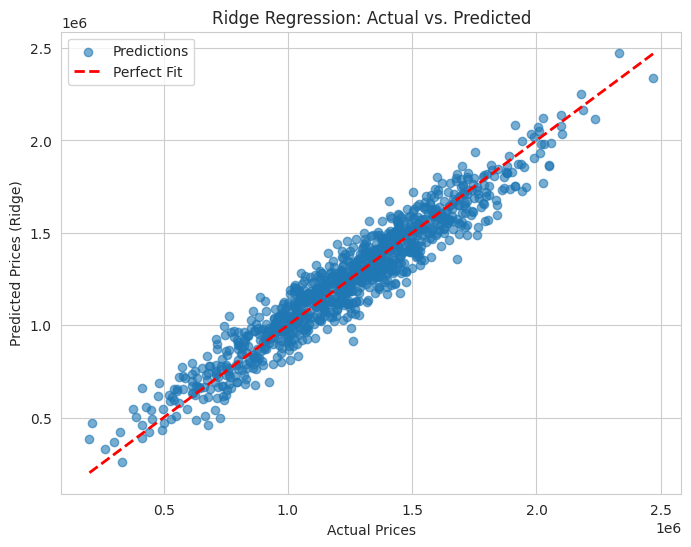

In [7]:
if 'X_train' in locals():
    param_grid = {'regressor__alpha': [0.01, 0.1, 1, 10, 100]}

    print("\n--- Training L1 (Lasso) Model ---")

    pipeline_lasso = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', Lasso(max_iter=2000))])

    grid_search_lasso = GridSearchCV(pipeline_lasso, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search_lasso.fit(X_train, y_train)

    y_pred_lasso = grid_search_lasso.predict(X_test)
    r2_lasso = r2_score(y_test, y_pred_lasso)
    print(f"Best Lasso Alpha: {grid_search_lasso.best_params_['regressor__alpha']}")
    print(f"Lasso Model R-squared (R²): {r2_lasso:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred_lasso, alpha=0.6, label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices (Lasso)")
    plt.title("Lasso Regression: Actual vs. Predicted")
    plt.legend()
    plt.show()

    print("\n--- Training L2 (Ridge) Model ---")

    pipeline_ridge = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', Ridge())])

    grid_search_ridge = GridSearchCV(pipeline_ridge, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search_ridge.fit(X_train, y_train)

    y_pred_ridge = grid_search_ridge.predict(X_test)
    r2_ridge = r2_score(y_test, y_pred_ridge)
    print(f"Best Ridge Alpha: {grid_search_ridge.best_params_['regressor__alpha']}")
    print(f"Ridge Model R-squared (R²): {r2_ridge:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred_ridge, alpha=0.6, label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices (Ridge)")
    plt.title("Ridge Regression: Actual vs. Predicted")
    plt.legend()
    plt.show()

else:
    print("Please run Cell 2 first to load and prepare the data.")